# Replicating Machnes paper results
## 1. Ideal pulse sequence.
First, the paper describes an ideal pulse sequence. Assuming $\eta\Omega \gg \nu$ and ignoring the free evolution for the duration of the pulses, the trotter cycle described in Machnes et al. consists of the following steps:
* $X\sigma_{y}$ pulse for dt
 $$
 H_{X\sigma_{y}} = \eta \Omega_T (a + a^{\dagger}) \sigma_{y}
$$
* Free evolution for dt
 $$
 H_{free} = \nu (a^{\dagger}a + \frac{1}{2})
 $$
 * $-X\sigma_{y}$ pulse for dt
 $$
    H_{-X\sigma_{y}} = -\eta \Omega_T (a + a^{\dagger}) \sigma_{y}
$$ 
* $X\sigma_{x}$ pulse for dt
 $$
 H_{X\sigma_{x}} = \eta \Omega_T (a + a^{\dagger}) \sigma_{x}
$$


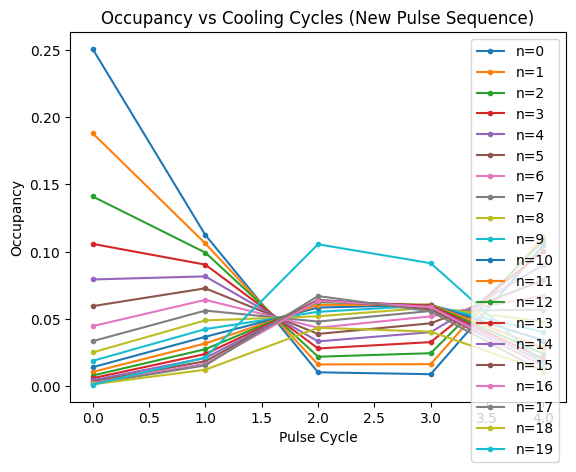

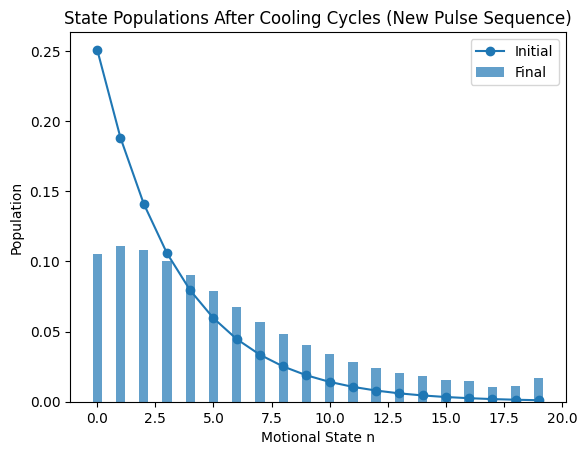

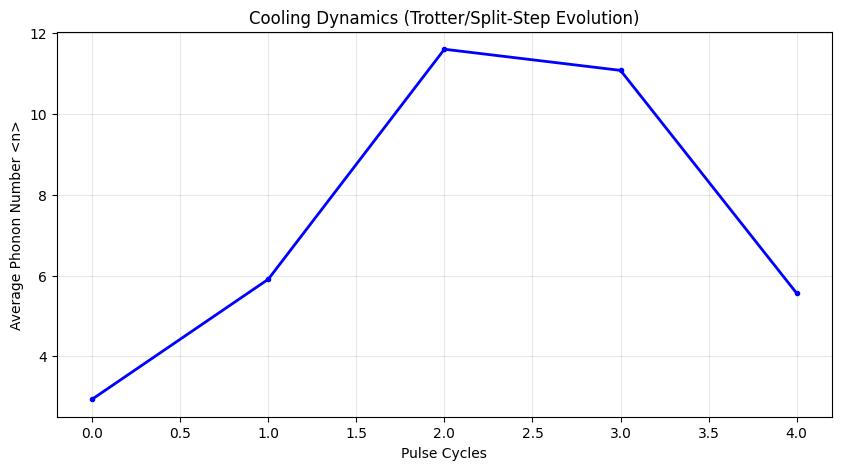

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

# Define system parameters
Delta = 1  # Detuning
RF_strength = 1  # RF dipolar coupling strength
nu = 1.0     # Motional frequency
eta = 0.1   # Lamb-Dicke parameter
N = 20  # Truncation for the Fock space
n_trotter = 180  # Number of Trotter cycles 
num_pulses = 4       
Omega_T = 1000  # Boosting Omega to approach Strong Coupling [cite: 10]
n_thermal = 3  # Average thermal phonon number
Omega = nu
n0 = 1
gamma = 5  # Spin relaxation
kT = 100      # Boltzmann constant times temperature

# --- FIX: Pulse parameters ---
tau_free =  10 # Ratio of free evolution to pulse duration
# Pulse duration from condition
total_time = 1
dt = total_time / (tau_free * Omega_T)

# QHO operators
a = destroy(N)  # Annihilation operator
a_dag = a.dag()  # Creation operator
xop = a + a_dag  # Position operator

# Spin operators
sz = sigmaz()
s_plus = sigmap()
s_minus = sigmam()
s_y = sigmay()
s_x = sigmax()

# Full size operators
s_z_full = tensor(sz, qeye(N))
s_plus_full = tensor(s_plus, qeye(N))
s_minus_full = tensor(s_minus, qeye(N))
s_y_full = tensor(s_y, qeye(N))
a_full = tensor(qeye(2), a)
a_dag_full = tensor(qeye(2), a_dag)
s_minus_full = tensor(s_minus, qeye(N))
s_x_full = tensor(s_x, qeye(N))
X_op = a_full + a_dag_full

"""Trotter pulse sequence Hamiltonians"""

# 1) X sy pulse Hamiltonian
H_Y = eta * Omega_T * (a_full + a_dag_full) * s_y_full
L_Y = liouvillian(H_Y)
U_Y = (L_Y * dt).expm()

# 2) Free evolution Hamiltonian
H_free = nu * (a_dag_full * a_full + 1/2)
L_free = liouvillian(H_free)
U_free = (L_free * tau_free * dt).expm()

# 3) Y -sy pulse Hamiltonian
# FIX: Use eta instead of nu
H_Y_undo = -eta * Omega_T * (a_full + a_dag_full) * s_y_full
L_Y_undo = liouvillian(H_Y_undo)
U_Y_undo = (L_Y_undo * dt).expm()

# 4) Another X sx pulse Hamiltonian
H_X_sx = eta * Omega_T * (a_full + a_dag_full) * s_x_full
L_X_sx = liouvillian(H_X_sx)
U_X_sx = (L_X_sx * dt).expm()

# Build the full propagator for one Trotter cycle
prop_trotter = U_X_sx * U_Y_undo * U_free * U_Y

# Add a relaxation step to reinitiate the internal dof
c_op = np.sqrt(gamma * (1 + n0)) * s_minus_full
L_relax = liouvillian(0 * s_z_full, [c_op])
U_relax = (L_relax * dt).expm()
prop_cycle = U_relax * (prop_trotter**n_trotter)

times_sim = np.arange(num_pulses + 1)  # Integer steps for cycles

# Initial state: spin in ground, motion thermal
thermal_state = thermal_dm(N, n_thermal)
ground_state = basis(2, 1)
initial_state = tensor(ground_state * ground_state.dag(), thermal_state)

# Storage
occupancies_fast = np.zeros((num_pulses + 1, N))
rho_current = operator_to_vector(initial_state)

# Initial occupancy
occupancies_fast[0, :] = initial_state.ptrace(1).diag().real
# Calculate initial energy
n_start = expect(a_dag_full * a_full, initial_state)
avg_energy = []
avg_energy.append(n_start)

# Evolve step-by-step under the new pulse sequence
for k in range(1, num_pulses + 1):
    rho_current = prop_cycle * rho_current
    
    # Store data
    rho_mat = vector_to_operator(rho_current)
    n_avg = expect(a_dag_full * a_full, rho_mat)
    avg_energy.append(n_avg)
    occupancies_fast[k, :] = rho_mat.ptrace(1).diag().real

# Plot the occupancy of all motional states over cycles
plt.figure()
for n in range(N):
    plt.plot(times_sim, occupancies_fast[:, n], '.-', label=f'n={n}')
plt.xlabel('Pulse Cycle')
plt.ylabel('Occupancy')
plt.title('Occupancy vs Cooling Cycles (New Pulse Sequence)')
plt.legend()
plt.show()

# Bar plot
p_motional_initial = occupancies_fast[0, :]
p_motional_final = occupancies_fast[-1, :]
plt.figure()
plt.plot(np.arange(N), p_motional_initial, 'o-', label='Initial')
plt.bar(np.arange(N), p_motional_final, width=0.4, label='Final', alpha=0.7)
plt.xlabel('Motional State n')
plt.ylabel('Population')
plt.title('State Populations After Cooling Cycles (New Pulse Sequence)')
plt.legend()
plt.show()

# Plot average phonon number over cycles
plt.figure(figsize=(10, 5))
plt.plot(range(num_pulses + 1), avg_energy, 'b.-', linewidth=2)
plt.xlabel('Pulse Cycles')
plt.ylabel('Average Phonon Number <n>')
plt.title('Cooling Dynamics (Trotter/Split-Step Evolution)')
plt.grid(True, alpha=0.3)
plt.show()